In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
x = np.arange(0, 270, 10)
y = np.sin(np.pi * x / 180)

In [3]:
df = pd.DataFrame({'x' : x, 'y' : y})
df.head()

,x,y
0,0,0.000000
1,10,0.173648
2,20,0.342020
3,30,0.500000
4,40,0.642788


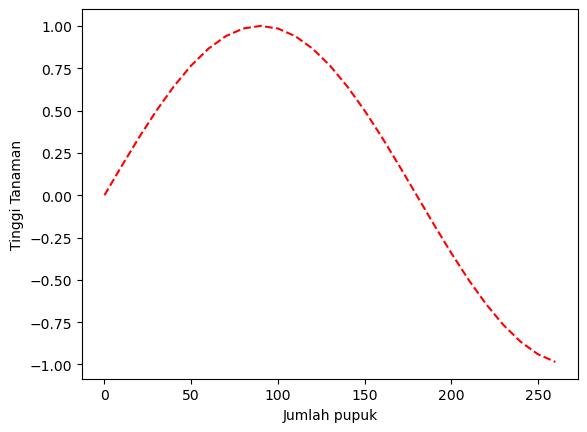

In [5]:
plt.plot(df['x'], df['y'], 'r--')
plt.xlabel("Jumlah pupuk")
plt.ylabel("Tinggi Tanaman")
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
Model  = LinearRegression()

In [8]:
X = df[['x']]
y = df['y']

In [9]:
Model.fit(X, y)

LinearRegression()

In [10]:
df['y_pred'] = Model.predict(X)

In [11]:
df.head()

,x,y,y_pred
0,0,0.000000,1.025479
1,10,0.173648,0.964302
2,20,0.342020,0.903126
3,30,0.500000,0.841950
4,40,0.642788,0.780773


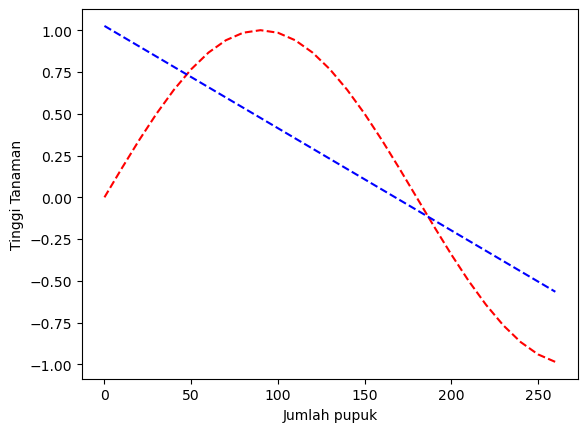

In [12]:
plt.plot(df['x'], df['y'], 'r--')
plt.plot(df['x'], df['y_pred'], 'b--')
plt.xlabel("Jumlah pupuk")
plt.ylabel("Tinggi Tanaman")
plt.show()

In [13]:
df['x2'] = df['x'] ** 2
df['x3'] = df['x'] ** 3

In [14]:
df.head()

,x,y,y_pred,x2,x3
0,0,0.000000,1.025479,0,0
1,10,0.173648,0.964302,100,1000
2,20,0.342020,0.903126,400,8000
3,30,0.500000,0.841950,900,27000
4,40,0.642788,0.780773,1600,64000


In [15]:
Model_1 = LinearRegression()

In [16]:
X_1 = df[['x', 'x2', 'x3']]
y_1 = df['y']

In [17]:
Model_1.fit(X_1, y_1)

LinearRegression()

In [18]:
df['y_pred2'] = Model_1.predict(X_1)

In [19]:
df.head()

,x,y,y_pred,x2,x3,y_pred2
0,0,0.000000,1.025479,0,0,-0.134816
1,10,0.173648,0.964302,100,1000,0.146618
2,20,0.342020,0.903126,400,8000,0.382679
3,30,0.500000,0.841950,900,27000,0.575862
4,40,0.642788,0.780773,1600,64000,0.728663


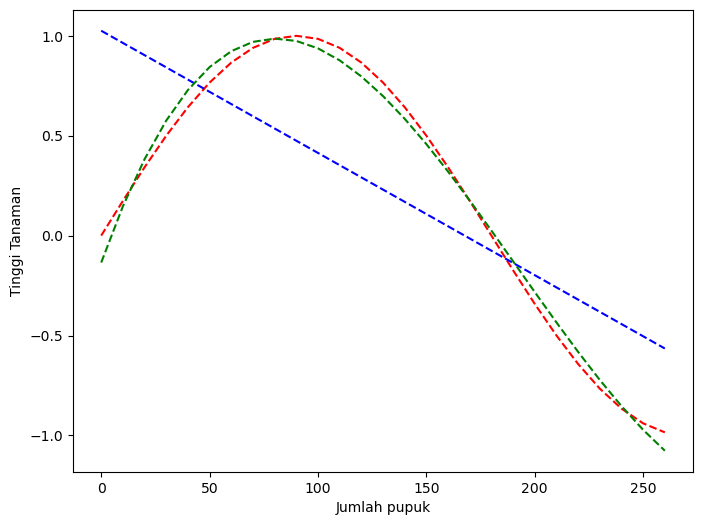

In [24]:
plt.figure(figsize=(8, 6))
plt.plot(df['x'], df['y'], 'r--') ## Aktual
plt.plot(df['x'], df['y_pred'], 'b--') ## Prediksi menggunakan LinReg
plt.plot(df['x'], df['y_pred2'], 'g--') ## Prediksi dg LinReg tetapi menggunakan Fitur sintetis hasil pangkat
plt.xlabel("Jumlah pupuk")
plt.ylabel("Tinggi Tanaman")
plt.show()

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Eva Metrics Model LinReg menggunakan Fitur Original

In [26]:
r2_LinReg = r2_score(df['y'], df['y_pred']) ## R2 adari prediksi Linear Regression
r2_LinReg

0.5298716618629806

In [27]:
MAE_LinReg = mean_absolute_error(df['y'], df['y_pred'])
MAE_LinReg

0.38994717307047794

In [28]:
MSE_LinReg = mean_squared_error(df['y'], df['y_pred'])
MSE_LinReg

0.20144802592224537

In [29]:
RMSE_LinReg = np.sqrt(MSE_LinReg)
RMSE_LinReg

0.44882961792003584

## Eva Metrics Model LinReg Menggunakan Fitur yg telah di-Engineer (Features Engineering)

In [30]:
r2_FE = r2_score(df['y'], df['y_pred2']) 
r2_FE

0.9920974829695088

In [31]:
MAE_FE = mean_absolute_error(df['y'], df['y_pred2'])
MAE_FE

0.05046996232943329

In [32]:
MSE_FE = mean_squared_error(df['y'], df['y_pred2'])
MSE_FE

0.003386195484232654

In [33]:
RMSE_FE = np.sqrt(MSE_FE)
RMSE_FE

0.05819102580495255

In [34]:
eva_data = {
"LinReg" : [r2_LinReg, MAE_LinReg, MSE_LinReg, RMSE_LinReg],
"FeaturesEngineering" : [r2_FE, MAE_FE, MSE_FE, RMSE_FE]}

In [35]:
pd.DataFrame(eva_data, index=["R2", "MAE", "MSE", "RMSE"])

,LinReg,FeaturesEngineering
R2,0.529872,0.992097
MAE,0.389947,0.050470
MSE,0.201448,0.003386
RMSE,0.448830,0.058191


In [2]:
## Feature Engineering - Transform : Polynomial Features (Pangkat)

In [3]:
x = np.arange(0, 360, 10)
y = np.cos(x * np.pi / 90)

df = pd.DataFrame({'x' : x,'y' : y})


In [4]:
df.head()

,x,y
0,0,1.000000
1,10,0.939693
2,20,0.766044
3,30,0.500000
4,40,0.173648


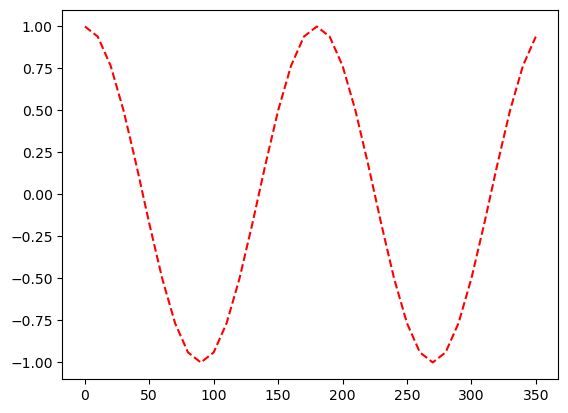

In [7]:
plt.plot(df['x'], df['y'], 'r--')
plt.show()

In [8]:
### Polynomial Features menggunakan Fungsi

In [9]:
from sklearn.preprocessing import PolynomialFeatures

In [14]:
a = [[2]]

a = [[5]] itu sama formatnya dengan Features untuk Machine Learning

In [17]:
Poly = PolynomialFeatures(degree = 5, include_bias = False)

In [16]:
Poly.fit_transform(a)

array([[ 1.,  2.,  4.,  8., 16., 32.]])

In [ ]:
2^0, 2^1, 2^2, 2^3, 2^4, 2^5

In [18]:
Poly.fit_transform(a)

array([[ 2.,  4.,  8., 16., 32.]])

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = df[['x']]
y = df['y']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = .80, random_state = 800)

In [22]:
Poli = PolynomialFeatures(degree=4, include_bias=False)

In [23]:
Poli = Poli.fit(X_train) ### .fit() hanya untuk Data Train, untuk menghindari Data Leakage

In [24]:
X_trainPoli = Poli.transform(X_train)
X_testPoli = Poli.transform(X_test)

Data Leakage ==> Kondisi ketika tanpa sengaja Model Melihat / Mempelajari / Mengetahui Kondisi dari data test
Tanpa sengaja kita melakukan .fit() terhadap data test

In [25]:
X_train.head()

,x
9,90
4,40
24,240
27,270
3,30


In [27]:
X_trainPoli

array([[9.000000e+01, 8.100000e+03, 7.290000e+05, 6.561000e+07],
       [4.000000e+01, 1.600000e+03, 6.400000e+04, 2.560000e+06],
       [2.400000e+02, 5.760000e+04, 1.382400e+07, 3.317760e+09],
       [2.700000e+02, 7.290000e+04, 1.968300e+07, 5.314410e+09],
       [3.000000e+01, 9.000000e+02, 2.700000e+04, 8.100000e+05],
       [2.000000e+02, 4.000000e+04, 8.000000e+06, 1.600000e+09],
       [8.000000e+01, 6.400000e+03, 5.120000e+05, 4.096000e+07],
       [3.200000e+02, 1.024000e+05, 3.276800e+07, 1.048576e+10],
       [2.900000e+02, 8.410000e+04, 2.438900e+07, 7.072810e+09],
       [3.000000e+02, 9.000000e+04, 2.700000e+07, 8.100000e+09],
       [1.300000e+02, 1.690000e+04, 2.197000e+06, 2.856100e+08],
       [3.300000e+02, 1.089000e+05, 3.593700e+07, 1.185921e+10],
       [6.000000e+01, 3.600000e+03, 2.160000e+05, 1.296000e+07],
       [2.100000e+02, 4.410000e+04, 9.261000e+06, 1.944810e+09],
       [1.100000e+02, 1.210000e+04, 1.331000e+06, 1.464100e+08],
       [1.700000e+02, 2.8

In [28]:
X_testPoli

array([[5.000000e+01, 2.500000e+03, 1.250000e+05, 6.250000e+06],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00],
       [1.000000e+02, 1.000000e+04, 1.000000e+06, 1.000000e+08],
       [3.400000e+02, 1.156000e+05, 3.930400e+07, 1.336336e+10],
       [2.800000e+02, 7.840000e+04, 2.195200e+07, 6.146560e+09],
       [1.400000e+02, 1.960000e+04, 2.744000e+06, 3.841600e+08],
       [2.300000e+02, 5.290000e+04, 1.216700e+07, 2.798410e+09],
       [7.000000e+01, 4.900000e+03, 3.430000e+05, 2.401000e+07]])

In [29]:
df_XtrainPoli = pd.DataFrame(X_trainPoli)

In [30]:
df_XtrainPoli.head()

,0,1,2,3
0,90.0,8100.0,729000.0,6.561000e+07
1,40.0,1600.0,64000.0,2.560000e+06
2,240.0,57600.0,13824000.0,3.317760e+09
3,270.0,72900.0,19683000.0,5.314410e+09
4,30.0,900.0,27000.0,8.100000e+05


In [31]:
### Model Training - Linear Regression

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
model_LR = LinearRegression()

In [35]:
model_LR.fit(X_train, y_train)

LinearRegression()

In [36]:
LR_train = model_LR.predict(X_train)

In [37]:
LR_test = model_LR.predict(X_test)

In [38]:
#### Model Training - Polynomial Features

In [39]:
model_PF = LinearRegression()

In [40]:
model_PF.fit(X_trainPoli, y_train)

LinearRegression()

In [41]:
PF_train = model_PF.predict(X_trainPoli)

In [42]:
PF_test = model_PF.predict(X_testPoli)

## Evaluation Metrics Comparison

In [46]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [43]:
## Linear Regression

In [44]:
## Training set

In [47]:
r2_LR = r2_score(y_train, LR_train) ## R2 dari Prediksi menggunakan Model Linear Regression
r2_LR

0.009872305117181623

In [49]:
MAE_LR = mean_absolute_error(y_train, LR_train)
MAE_LR

0.6365130866587257

In [50]:
MSE_LR = mean_squared_error(y_train, LR_train)
MSE_LR

0.49259713790626186

In [52]:
RMSE_LR = np.sqrt(MSE_LR)
RMSE_LR

0.7018526468613351

In [53]:
## Test Set

In [54]:
r2_LR_test = r2_score(y_test, LR_test) ## R2 dari Prediksi menggunakan Model Linear Regression
r2_LR_test

-0.08181889642916285

In [55]:
MAE_LR_test = mean_absolute_error(y_test, LR_test)
MAE_LR_test

0.6358716148252015

In [56]:
MSE_LR_test = mean_squared_error(y_test, LR_test)
MSE_LR_test

0.5262431979078159

In [57]:
RMSE_LR_test = np.sqrt(MSE_LR_test)
RMSE_LR_test

0.7254262181006529

In [58]:
## Polynomial Features

In [ ]:
## Training Set

In [59]:
r2_PF = r2_score(y_train, PF_train) ## R2 dari Prediksi menggunakan Model Linear Regression  dan Feature Engineering Polynomial Features
r2_PF

0.7111810183009264

In [60]:
MAE_PF = mean_absolute_error(y_train, PF_train)
MAE_PF

0.3480162302689807

In [61]:
MSE_PF = mean_squared_error(y_train, PF_train)
MSE_PF

0.14368995483436353

In [62]:
RMSE_PF = np.sqrt(MSE_PF)
RMSE_PF

0.3790645787123396

In [63]:
## Test Set

In [64]:
r2_PF_test = r2_score(y_test, PF_test) ## R2 dari Prediksi menggunakan Model Linear Regression  dan Feature Engineering Polynomial Features
r2_PF_test

0.2653165329350107

In [66]:
MAE_PF_test = mean_absolute_error(y_test, PF_test)
MAE_PF_test

0.38733553162439227

In [68]:
MSE_PF_test = mean_squared_error(y_test, PF_test)
MSE_PF_test

0.35738160835832417

In [69]:
RMSE_PF_test = np.sqrt(MSE_PF_test)
RMSE_PF_test

0.5978140248926285

In [71]:
eva_data = {
'LinReg Training' : [r2_LR, MAE_LR, MSE_LR, RMSE_LR],
'LinReg Testing' : [r2_LR_test, MAE_LR_test, MSE_LR_test, RMSE_LR_test],
'Polynomial Training' : [r2_PF, MAE_PF, MSE_PF, RMSE_PF],
'Polynomial Testing' : [r2_PF_test, MAE_PF_test, MSE_PF_test, RMSE_PF_test]}

In [72]:
pd.DataFrame(eva_data, index=['R2', 'MAE', 'MSE', 'RMSE'])

,LinReg Training,LinReg Testing,Polynomial Training,Polynomial Testing
R2,0.009872,-0.081819,0.711181,0.265317
MAE,0.636513,0.635872,0.348016,0.387336
MSE,0.492597,0.526243,0.143690,0.357382
RMSE,0.701853,0.725426,0.379065,0.597814


In [ ]:
## Hasil Polynomial sudah bagus, tetapi masih OverFit

In [ ]:
## Manual Tuning

In [ ]:
degree = [4,5,6,7,8,9]
r2_result = []
for i in degree:
    Poly = PolynomialFeatures(degree=i, include_bias=False)
    Poly.fit(X_train)
    X_trainP = Poly.transform(X_train)
    X_testP = Poly.transform(X_test)
    Model.fit(X_trainP, y_train)
    y_pred = Model.predict(X_testP)
    r2 = r2_score(y_test, y_pred)
    r2_result.append(r2)